**Summary of the Dataset.**

The dataset contains the global chocolate product sales from the year July 2022 to December 2025.
Through this dataset the company Sales Manager wants to know the sales performance of different chocolates globally so that they can make efficient decisions for next year production, distribution and marketing.
Here, based on the data given, As a business analyst, I need to analyze the dataset and provide them the insights from the dataset for them to make decisons.

**Questions to be answered.**

1) What is the overall sales trend over time?
2) Which month has the highest and lowest sales?
3) Which product generates the most revenue?
4) Which product has high volume but low revenue?
5) Which country contributes most to total sales?
6) Which salesperson is the top and bottom performer?
7) Different correlations and insights.
8) Which salesperson performs best in which country?

In [1]:
# Importing the libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importing the dataset
dataset = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\Data_Analysis class Mindrisers\Mindrisers project\EDA SELF PROJECT\uncleaned data project\Chocolate Sales.csv")

In [3]:
# Checking the first 3 data (Head)
dataset.head(3)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91


In [4]:
# Checking the last 3 data (Tail)
dataset.tail(3)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397
3281,Karlen McCaffrey,India,70% Dark Bites,23/05/2024,"$5,915.87",355


In [5]:
# Checking the duplicates
print(dataset.duplicated().sum())

0


*There are no duplicates to be found in the dataset.*

In [6]:
# Checking the null values
print(dataset.isnull().sum())

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


*There are no duplicates to be found. Hence, the dataset is clean.*

**Basic information of the dataset.**

In [7]:
# Columns name.
print(dataset.columns)

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')


In [8]:
# Chekcing the number of rows and columns.
dataset.shape

(3282, 6)

*There are 3282 rows and 6 columns.*

In [9]:
#Cheking the type of data in dataset.
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [10]:
# Checking the basic statistical value of the data.
dataset.describe()

,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


In [11]:
# Using the datetime function to separate date to different sections (day,month,year)
dataset['Date'] = pd.to_datetime(dataset['Date'],dayfirst= True)
dataset['Day'] = dataset['Date'].dt.day_name()
dataset['Month'] = dataset['Date'].dt.month_name()
dataset['Year'] = dataset['Date'].dt.year

In [12]:
# Dropping the date section as now the dates have been separated
dataset.drop('Date', axis= 1, inplace= True)

In [13]:
# Converting the column which was in object to float 
dataset['Amount'] = dataset['Amount'].str.replace('$','').str.replace(',','').astype(float)

In [14]:
# Creating a new column per price box
dataset['Price Per Box'] = dataset['Amount']/dataset['Boxes Shipped']

**Checking the unique values for the dataset.**

In [15]:
# For Country
Countries = dataset['Country'].sort_values(ascending = True).unique()
print(f'The different countries are: {Countries}')

The different countries are: ['Australia' 'Canada' 'India' 'New Zealand' 'UK' 'USA']


In [16]:
# For Salesperson
salesperson = dataset['Sales Person'].unique()
print(f'The different sales person are: {salesperson}')

The different sales person are: ['Jehu Rudeforth' 'Van Tuxwell' 'Gigi Bohling' 'Jan Morforth' 'Oby Sorrel'
 'Gunar Cockshoot' 'Brien Boise' 'Rafaelita Blaksland' 'Barr Faughny'
 'Mallorie Waber' 'Karlen McCaffrey' "Marney O'Breen" 'Beverie Moffet'
 'Roddy Speechley' 'Curtice Advani' 'Husein Augar' 'Kaine Padly'
 'Dennison Crosswaite' "Wilone O'Kielt" 'Andria Kimpton' 'Kelci Walkden'
 'Camilla Castle' 'Madelene Upcott' 'Dotty Strutley' 'Ches Bonnell']


In [17]:
# Different Products
products = dataset['Product'].unique()
print(f'The different products are: {products}')

The different products are: ['Mint Chip Choco' '85% Dark Bars' 'Peanut Butter Cubes'
 'Smooth Sliky Salty' '99% Dark & Pure' 'After Nines' '50% Dark Bites'
 'Orange Choco' 'Eclairs' 'Drinking Coco' 'Organic Choco Syrup'
 'Milk Bars' 'Spicy Special Slims' 'Fruit & Nut Bars' 'White Choc'
 'Manuka Honey Choco' 'Almond Choco' 'Raspberry Choco'
 'Choco Coated Almonds' "Baker's Choco Chips" 'Caramel Stuffed Bars'
 '70% Dark Bites']


In [18]:
# Different Years
years = dataset['Year'].unique()
print(f'The different years are: {years}')

The different years are: [2022 2023 2024]


**Checking months for different year for better insights.**

In [19]:
year_2022 = dataset[dataset['Year']== 2022]['Month'].unique()
print(f'The different months in the year 2022 are: {year_2022}')

The different months in the year 2022 are: ['January' 'August' 'July' 'April' 'February' 'June' 'March' 'May']


In [20]:
year_2023 = dataset[dataset['Year']== 2023]['Month'].unique()
print(f'The different months in the year 2023 are: {year_2023}')

The different months in the year 2023 are: ['January' 'August' 'July' 'April' 'February' 'June' 'March' 'May']


In [21]:
year_2024 = dataset[dataset['Year']== 2024]['Month'].unique()
print(f'The different months in the year 2024 are: {year_2024}')

The different months in the year 2024 are: ['January' 'August' 'July' 'April' 'February' 'June' 'March' 'May']


*From the datset, we can see that the months given are incomplete where only months ranging from January to August are only given for the years 2022-2024. It can be beacause the company wanted to see the performance of chocolate sales from the month of Jan to Aug, and only on the basis of the peroformance they they want to decide what to do for the later months.*

**Checking the information of the other datas.**

In [22]:
dataset.describe(include= object)

,Sales Person,Country,Product,Day,Month
count,3282,3282,3282,3282,3282
unique,25,6,22,7,8
top,Kelci Walkden,Australia,50% Dark Bites,Thursday,June
freq,162,615,180,669,489


*Answering the business related questions for deep isights and information.*

In [23]:
# 1) What is the overall sales trend over time?
sales_trend = dataset.groupby('Year')['Amount'].sum()
print(sales_trend)

Year
2022    6183625.00
2023    6643377.96
2024    6964568.90
Name: Amount, dtype: float64


In [40]:
# 2) Which month has the highest and lowest sales?
high_month_sales_2022 = dataset[dataset['Year']==2022].groupby('Month')['Amount'].sum().sort_values(ascending= False)
print(high_month_sales_2022)

Month
January     896105.0
June        865144.0
July        803425.0
May         752892.0
March       749483.0
August      743148.0
February    699377.0
April       674051.0
Name: Amount, dtype: float64


*January had the highest sales followed by June and July whereas April had the lowest sales followed by February and August for year 2022.*

In [28]:
high_month_sales_2023 = dataset[dataset['Year']== 2023].groupby('Month')['Amount'].sum().sort_values(ascending= False)
print(high_month_sales_2023)

Month
January     958985.77
June        932625.17
July        861856.66
May         811951.78
March       807494.33
August      793103.07
February    749617.46
April       727743.72
Name: Amount, dtype: float64


*January had the highest sales followed by June and July whereas April had the lowest sales followed by February and August for year 2023.*

In [31]:
high_month_sales_2024 = dataset[dataset['Year']==2024].groupby('Month')['Amount'].sum().sort_values(ascending= False)
print(high_month_sales_2024)

Month
January     1013621.82
June         976162.77
July         902250.63
May          850906.79
March        847791.96
August       830599.99
February     783102.44
April        760132.50
Name: Amount, dtype: float64


*January had the highest sales followed by June and July whereas April had the lowest sales followed by February and August for year 2024.*

In [33]:
# 3) Which product generates the most revenue?
highest_revenue_generator = dataset.groupby('Product')['Amount'].sum().sort_values(ascending= False)
print(highest_revenue_generator)

Product
Smooth Sliky Salty      1120201.09
50% Dark Bites          1087659.35
White Choc              1054257.00
Peanut Butter Cubes     1036591.09
Eclairs                  996947.96
99% Dark & Pure          960033.45
85% Dark Bars            955268.24
Organic Choco Syrup      945345.73
Spicy Special Slims      938131.69
Mint Chip Choco          904989.55
Almond Choco             890454.65
Manuka Honey Choco       885208.03
Milk Bars                866273.62
Raspberry Choco          845388.41
After Nines              837215.67
Fruit & Nut Bars         829278.96
Orange Choco             824070.85
Drinking Coco            822245.57
Baker's Choco Chips      799085.67
Choco Coated Almonds     773062.91
Caramel Stuffed Bars     742516.15
70% Dark Bites           677346.22
Name: Amount, dtype: float64


*Smooth Silky Salty product is the highest revenue generator chocolate product followed by 50% Dark Bites and White Choc.*

In [36]:
# 4) Which product has high volume but low revenue?
high_volume_low_revenue = dataset.groupby('Product')[['Boxes Shipped','Amount']].sum().sort_values(by= 'Boxes Shipped', ascending= False)
high_volume_low_revenue

avg_boxes = high_volume_low_revenue['Boxes Shipped'].mean()
avg_amount = high_volume_low_revenue['Amount'].mean()
result = high_volume_low_revenue[(high_volume_low_revenue['Boxes Shipped'] > avg_boxes) & (high_volume_low_revenue['Amount'] < avg_amount)].sort_values(by= 'Boxes Shipped', ascending= False)
result

,Boxes Shipped,Amount
Product,,
Caramel Stuffed Bars,26576,742516.15
Drinking Coco,26402,822245.57
Milk Bars,25436,866273.62
After Nines,25156,837215.67


*Caramel Stuffed Bars had the highest volume of boxes shipped but had the lowest revenue generated followed by Drinnking Coco and Milk Bars.*

In [38]:
# 5) Which country contributes most to total sales?
highest_revenue_generator_country = dataset.groupby('Country')['Amount'].sum().sort_values(ascending= False)
print(highest_revenue_generator_country)

Country
Australia      3646444.35
UK             3365388.90
India          3343730.83
USA            3313858.09
Canada         3078495.65
New Zealand    3043654.04
Name: Amount, dtype: float64


*Australia has the highest contribution to total sales of chocolates followed by UK and India.*

In [88]:
# 6) Which salesperson is the top and bottom performer?
salesperson_performance = dataset.groupby('Sales Person')['Amount'].sum().sort_values(ascending= False)
print(salesperson_performance)

Sales Person
Ches Bonnell           1022599.96
Oby Sorrel             1017204.12
Madelene Upcott        1010028.72
Kelci Walkden          1002929.10
Brien Boise             997326.48
Van Tuxwell             974425.09
Dennison Crosswaite     931849.57
Beverie Moffet          892421.37
Kaine Padly             849062.76
Marney O'Breen          836427.63
Barr Faughny            830826.91
Roddy Speechley         808359.58
Gunar Cockshoot         762283.43
Gigi Bohling            742296.51
Karlen McCaffrey        713832.64
Jehu Rudeforth          708505.03
Jan Morforth            706585.50
Curtice Advani          691797.92
Rafaelita Blaksland     668865.45
Husein Augar            656149.73
Andria Kimpton          648214.81
Mallorie Waber          642903.33
Camilla Castle          628613.13
Dotty Strutley          608101.17
Wilone O'Kielt          439961.92
Name: Amount, dtype: float64


*Ches Bonnell was the top performer followed by Oby Sorrel and Madelene Upcott whereas Wilone O'Kielt was the bottom performer followed by Dotty Strutley and Camilla Castle.*

**Visualization of the questions.**

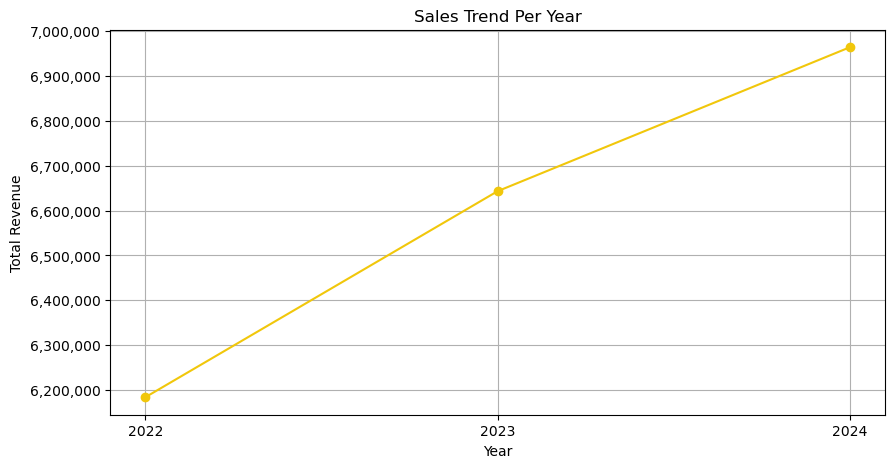

In [67]:
# Sales trend
plt.figure(figsize=(10,5))
plt.plot(sales_trend.index, sales_trend.values, color = "#F1C70B",marker = 'o')
plt.title('Sales Trend Per Year')
plt.grid(True)
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.xticks([2022,2023,2024])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()

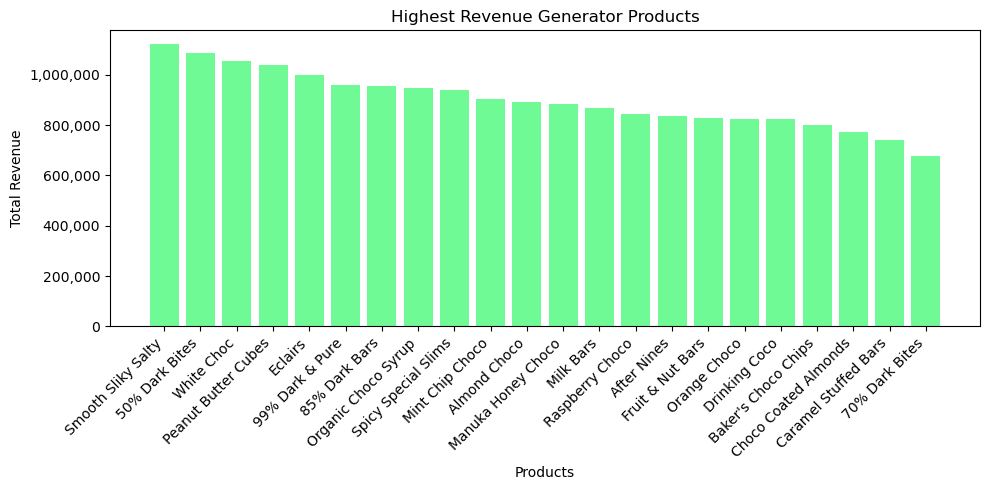

In [73]:
# Product revenue generator
plt.figure(figsize=(10,5))
plt.bar(highest_revenue_generator.index,highest_revenue_generator.values,color="#09F74994")
plt.title('Highest Revenue Generator Products')
plt.xlabel('Products')
plt.ylabel('Total Revenue')
plt.xticks(rotation = 45, ha = 'right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

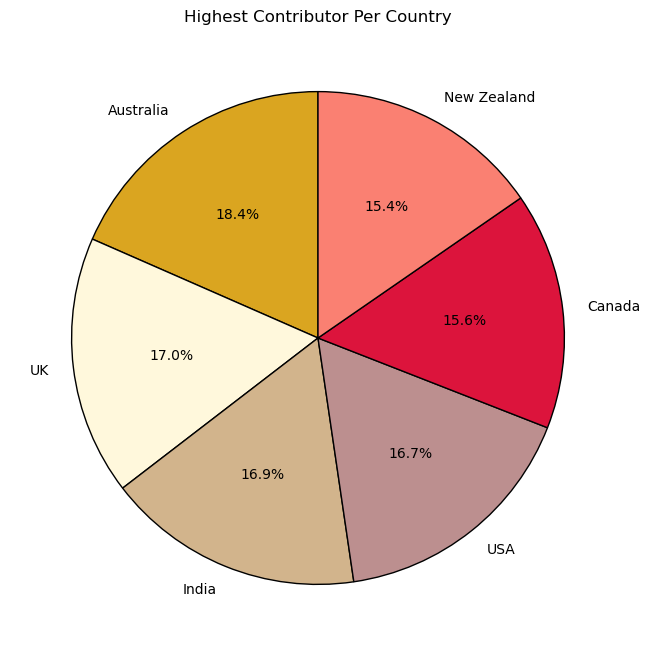

In [86]:
# Country Contribution
plt.figure(figsize=(8,8))
plt.pie(highest_revenue_generator_country, labels= highest_revenue_generator_country.index,autopct='%1.1f%%',startangle=90, colors = ['goldenrod','cornsilk','tan','rosybrown','crimson','salmon'],wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Highest Contributor Per Country')
plt.show()



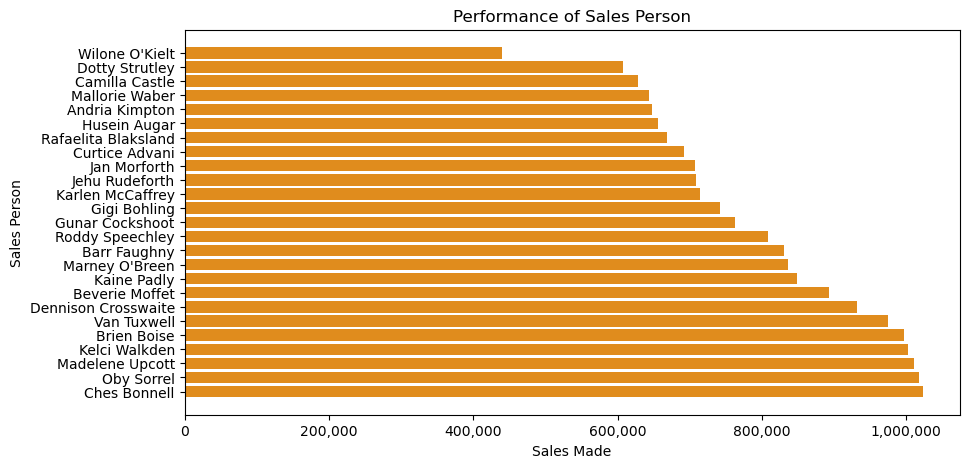

In [98]:
# Performer
plt.figure(figsize=(10,5))
plt.barh(salesperson_performance.index,salesperson_performance.values, color= "#E08C1D")
plt.title('Performance of Sales Person')
plt.xlabel('Sales Made')
plt.ylabel('Sales Person')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()

**Boxplots for Outliers**

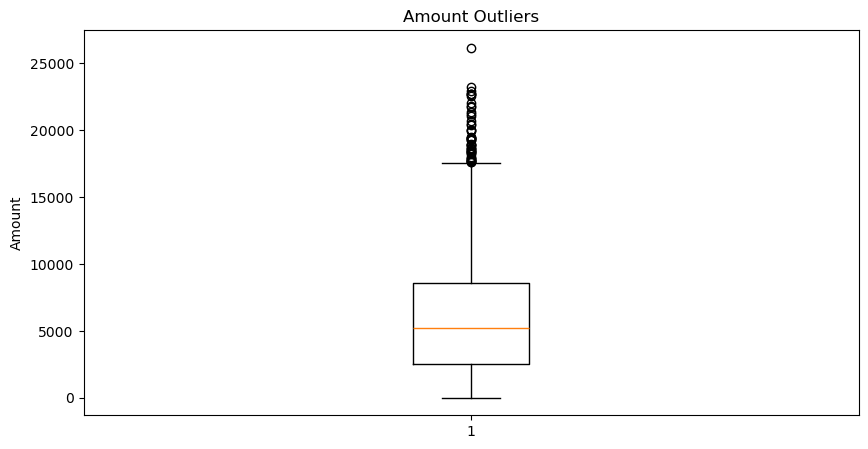

q1 is: 2521.495
q3 is: 8556.8425
IQR is: 6035.347500000001
lower bound is: -6531.526250000002
upper bound is: 17609.863750000004
Total Outliers: {len(outliers)}
             Sales Person      Country               Product    Amount  \
66            Van Tuxwell    Australia   Organic Choco Syrup  19453.00   
135           Van Tuxwell        India   Organic Choco Syrup  19929.00   
212        Marney O'Breen           UK    Smooth Sliky Salty  18991.00   
434          Jan Morforth  New Zealand       Mint Chip Choco  18340.00   
543          Ches Bonnell        India   Peanut Butter Cubes  22050.00   
589        Curtice Advani        India    Smooth Sliky Salty  19327.00   
609          Jan Morforth    Australia       Mint Chip Choco  17626.00   
751   Rafaelita Blaksland  New Zealand               Eclairs  19481.00   
806           Brien Boise        India         85% Dark Bars  18032.00   
1008          Kaine Padly           UK           After Nines  18697.00   
1151          Brien Boise

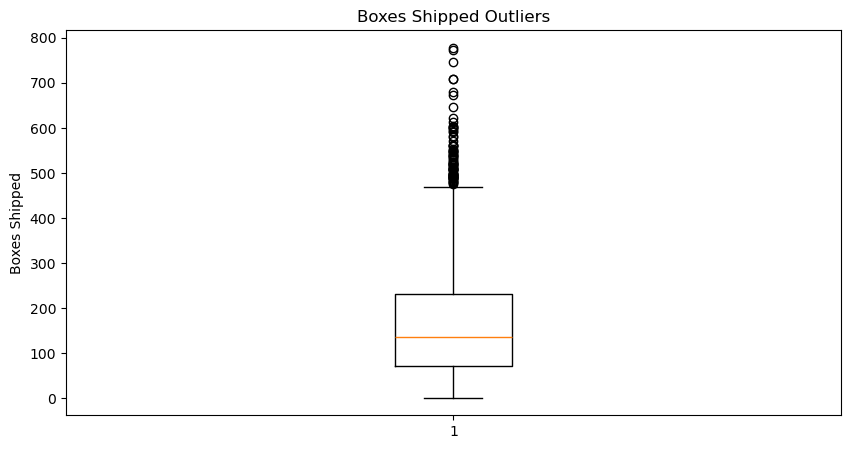

q1 is: 71.0
q3 is: 232.0
IQR is: 161.0
lower bound is: -170.5
upper bound is: 473.5
Total Outliers: {len(outliers)}
          Sales Person      Country               Product    Amount  \
39    Karlen McCaffrey        India    Manuka Honey Choco   2443.00   
97       Kelci Walkden           UK      Fruit & Nut Bars  13006.00   
109       Jan Morforth        India   Spicy Special Slims   1939.00   
121      Kelci Walkden    Australia               Eclairs   7273.00   
150     Camilla Castle    Australia        70% Dark Bites   6048.00   
...                ...          ...                   ...       ...   
3063    Beverie Moffet  New Zealand         Drinking Coco   1284.37   
3148    Jehu Rudeforth        India   Peanut Butter Cubes     33.68   
3166    Mallorie Waber       Canada  Caramel Stuffed Bars   5093.92   
3216       Van Tuxwell       Canada         Drinking Coco   5294.88   
3258        Oby Sorrel       Canada               Eclairs   6409.31   

      Boxes Shipped        Day 

In [102]:
columns = ['Amount', 'Boxes Shipped']
for col in columns:
    #Boxplot Creation
    plt.figure(figsize = (10,5))
    plt.boxplot(dataset[col])
    plt.title(f'{col} Outliers')
    plt.ylabel(col)
    plt.show()
    
    #Calculation of IQR
    q1 = dataset[col].quantile(0.25)
    q3 = dataset[col].quantile(0.75)
    IQR = q3 - q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    outliers = dataset[(dataset[col]<lower_bound)| (dataset[col]>upper_bound)]
    
    print(f'q1 is: {q1}')
    print(f'q3 is: {q3}')
    print(f'IQR is: {IQR}')
    print(f'lower bound is: {lower_bound}')
    print(f'upper bound is: {upper_bound}')
    print('Total Outliers: {len(outliers)}')
    print(outliers)
    

*The dots that can be seen on the boxplots are considered outliers. There can be seen many outliers in both amount and boxes shipped boxplots which is because the chocolates are shipped worldwide to differeent countries each months due to which different countries can order boxes in bulk amount which resulted outliers in boxes shipped boxplot. This directly affected the amount as higher the number of boxes shipped higher will be the sales amount.*

**Finding out the correlation between different factors.**

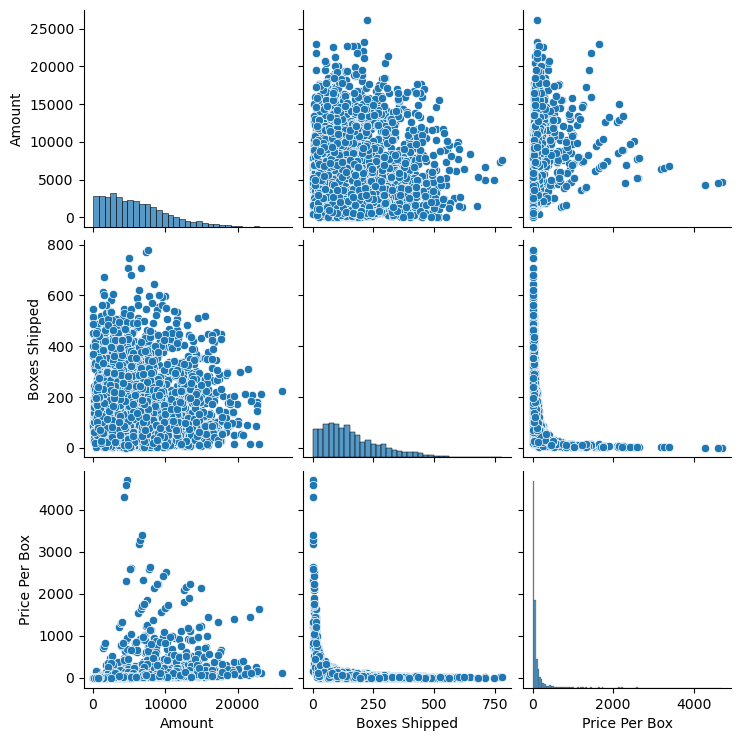

In [106]:
# For pairplot

pairplot = sns.pairplot(dataset[['Amount', 'Boxes Shipped', 'Price Per Box']])
print(pairplot)

In [ ]:
# Correaltion between amount and boxes shipped
correlation_1 = dataset[['Amount', 'Boxes Shipped']].corr()
print(correlation_1)

                 Amount  Boxes Shipped
Amount         1.000000      -0.013154
Boxes Shipped -0.013154       1.000000


*There is almost no correlation between boxes shipped and amount. This indicates that shipping more boxes does not lead to increase in amount (revenue) and vice versa.*

In [108]:
# Correlation between Boxes Shipped and Price per box
correlation_2 = dataset[['Boxes Shipped', 'Price Per Box']].corr()
print(correlation_2)

               Boxes Shipped  Price Per Box
Boxes Shipped       1.000000      -0.336027
Price Per Box      -0.336027       1.000000


*There is a negative correlation between boxes shipped and Price per box. This indicates that shipping more boxes does not lead to decrease in price per box (discount).*

In [109]:
# correlation between amount and price per box
correlation_3 = dataset[['Price Per Box', 'Amount']].corr()
print(correlation_3)

               Price Per Box    Amount
Price Per Box       1.000000  0.231108
Amount              0.231108  1.000000


*There is a positive correlation between Price Per box and amount. This indicates that increase in price per box leads to increase in amount(sales).*

In [110]:
# Merged Correlation
merged_correlation = dataset[['Price Per Box', 'Boxes Shipped', 'Amount']].corr()
print(merged_correlation)

               Price Per Box  Boxes Shipped    Amount
Price Per Box       1.000000      -0.336027  0.231108
Boxes Shipped      -0.336027       1.000000 -0.013154
Amount              0.231108      -0.013154  1.000000


**Heatmap Generation**

Axes(0.125,0.11;0.62x0.77)


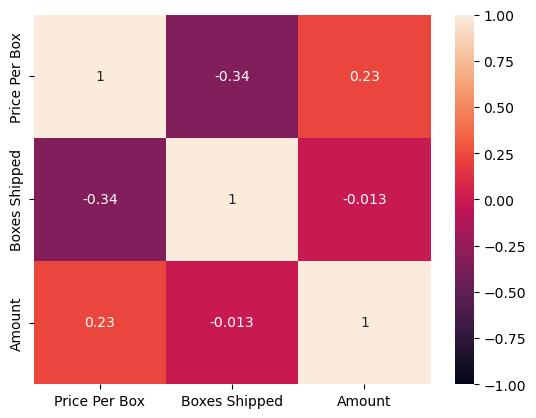

In [112]:
heatmap = sns.heatmap(merged_correlation,vmin = -1, vmax = 1, annot = True)
print(heatmap)

**Summary of the Dataset**

1) The sales were increasing on a consistent level on a yearly basis where in 2022 sales were 6183625 followed by the year 2023, sales were 6643377.96 and in 2024 sales were 6964568.90.

2) For every year staring from 2022 to 2024, January, June, and July have been in top 3 consistently in sales which indicates they had the highest sales. Additionally, April, February, and August were placed in bottom 3 for all the years (2022-2024) which shows they had the lowest sales.

3) In terms of product, Smooth Silky Salty product had the highest sales (1120201.09) followed by 50% Dark Bites (1087659.35) and White Choc (1054257.00) whereas 70% Dark Bites had the lowest sales (677346.22) followed by Caramel Stuffed Bars (742516.15) and Choco Coated Almonds (773062.91).

4) Caramel Stuffed Bars had the highest number of boxes shipped (26576) and the lowest revenue generated (742516.15) followed by Drinking Coco (26402) where revenue were (822245.57) and Milk Bars (25436) where revenue were (866273.57).

5) For country, Australia were the highest revenue generator which contributed to the most sales (3646444.35) followed by UK (3365388.90) and India (3343730.83).

6) In terms of salesperson, Ches Bonnell was the top performer (1022599.96) followed by Oby Sorrel (1017204.12) and Madelene Upcott (1010028.72). Moreover, Wilone O'Kielt was the bottom performer (439961.92) followed by Dotty Strutley (608101.17) and Camilla Castle (628613.13).

7) There is almost no correlation between boxes shipped and amount. This indicates that shipping more boxes does not lead to increase in amount (revenue) and vice versa.

8) There is a negative correlation between boxes shipped and Price per box. This indicates that shipping more boxes does not lead to decrease in price per box (discount).

9) There is a positive correlation between Price Per box and amount. This indicates that increase in price per box leads to increase in amount(sales).

10) There can be seen many outliers in both amount and boxes shipped boxplots which is because the chocolates are shipped worldwide to differeent countries each months due to which different countries can order boxes in bulk amount which resulted outliers in boxes shipped boxplot. This directly affected the amount as higher the number of boxes shipped higher will be the sales amount.

**Recommendations**

1) Since Jan, June, and July are the consistent month for every year hence, inventory for the product can be inncreased when these months are near and also premium products can also be introduced to maximmize sales. Similary, for the lower performing months like Feb, April and Aug disount campaigns can be introduced to increase the sales. Moreover, marketing can also be done to maximize sales.

2) For the high 